# Homework Assignment 3: Data Analysis & Optimization

# **[Ines Lopez-Silvero]**

**Total Points:** 100

**Instructions:**
- Complete all three problems in this notebook
- Write your code in the provided cells
- Run all cells to verify your code works
- Save your completed `.ipynb` file to the `homework` folder in your private GitHub repository (shared with the instructor)
- Submit the link to your notebook on Canvas

**⚠️ IMPORTANT:** GitHub records the timestamp of every file update. Your notebook must be committed to GitHub **before the deadline**. **DO NOT** update the file after the deadline—late modifications will be flagged and may result in a grade penalty.

**Academic Integrity:** This is an individual assignment. You may consult course materials, Python documentation, AI tools, and discuss concepts with classmates, but all code must be your own.

---

In [11]:
# Standard imports - run this cell first
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize, curve_fit

---
## Problem 1: Stream Water Quality Analysis (35 points)

You are analyzing water quality data from multiple stream monitoring sites in Wisconsin. The dataset contains measurements of temperature, dissolved oxygen (DO), pH, and conductivity collected over several months.

### Your Tasks:

**Part A (10 points):** Load and explore the data
1. Load the data from the CSV string provided below into a pandas DataFrame
2. Display basic information about the dataset (shape, data types, first few rows)
3. Check for missing values and report how many are in each column
4. Convert the `date` column to datetime format using `pd.to_datetime()`

**Part B (15 points):** Data analysis with grouping
1. Calculate the mean, standard deviation, min, and max for dissolved oxygen (`do_mg_l`) grouped by `site_id`
2. Determine which site has the lowest mean dissolved oxygen
3. Create a new column called `do_status` that classifies each measurement as:
   - "Critical" if DO < 4 mg/L
   - "Low" if DO is 4-6 mg/L
   - "Adequate" if DO is 6-8 mg/L
   - "Good" if DO ≥ 8 mg/L
4. Count how many measurements fall into each `do_status` category per site

**Part C (10 points):** Filtering and summary
1. Filter the data to include only measurements where temperature > 15°C AND pH is between 6.5 and 8.5
2. For this filtered subset, calculate the mean conductivity for each month (hint: extract month from date)
3. Identify which site-month combination had the highest number of "Critical" or "Low" DO readings

In [2]:
# Water quality dataset
water_quality_csv = """site_id,date,temp_c,do_mg_l,ph,conductivity_us
SITE_A,2024-05-15,12.3,9.2,7.1,245
SITE_A,2024-05-22,14.1,8.5,7.3,252
SITE_A,2024-06-05,16.8,7.2,7.0,268
SITE_A,2024-06-19,19.2,5.8,6.8,285
SITE_A,2024-07-03,22.5,4.5,6.9,312
SITE_A,2024-07-17,24.1,3.8,7.1,298
SITE_A,2024-08-01,23.8,4.2,7.2,305
SITE_A,2024-08-15,21.2,5.5,7.0,289
SITE_B,2024-05-15,11.8,10.1,7.4,198
SITE_B,2024-05-22,13.5,9.8,7.5,205
SITE_B,2024-06-05,15.9,8.9,7.3,215
SITE_B,2024-06-19,18.4,7.5,7.2,228
SITE_B,2024-07-03,21.2,6.2,7.1,245
SITE_B,2024-07-17,22.8,5.8,7.0,251
SITE_B,2024-08-01,22.1,6.1,7.1,248
SITE_B,2024-08-15,20.5,7.0,7.2,235
SITE_C,2024-05-15,13.1,8.8,6.2,312
SITE_C,2024-05-22,14.8,8.1,6.4,325
SITE_C,2024-06-05,17.2,6.5,6.3,348
SITE_C,2024-06-19,20.1,5.2,6.1,372
SITE_C,2024-07-03,23.4,3.5,6.0,398
SITE_C,2024-07-17,25.2,2.8,5.9,412
SITE_C,2024-08-01,24.5,3.2,6.1,405
SITE_C,2024-08-15,22.3,4.1,6.2,385"""

# Part A: Load and explore the data
import pandas as pd
from io import StringIO
# Hint: Use pd.read_csv(StringIO(water_quality_csv))
water_quality_df= pd.read_csv(StringIO(water_quality_csv))
water_quality_df

print(f"Shape:{water_quality_df.shape}")
print(f"Data types:\n{water_quality_df.dtypes}")
print("\nRows 1-5:")
water_quality_df.iloc[1:6]


print("Missing values per column:")
print(water_quality_df.isna().sum())

water_quality_df['date']=pd.to_datetime(water_quality_df['date'])
water_quality_df.info()








Shape:(24, 6)
Data types:
site_id             object
date                object
temp_c             float64
do_mg_l            float64
ph                 float64
conductivity_us      int64
dtype: object

Rows 1-5:
Missing values per column:
site_id            0
date               0
temp_c             0
do_mg_l            0
ph                 0
conductivity_us    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   site_id          24 non-null     object        
 1   date             24 non-null     datetime64[ns]
 2   temp_c           24 non-null     float64       
 3   do_mg_l          24 non-null     float64       
 4   ph               24 non-null     float64       
 5   conductivity_us  24 non-null     int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 1.3+ KB


In [23]:
# Part B: Data analysis with grouping
site_stats = water_quality_df.groupby('site_id')['do_mg_l'].agg(['mean','min','max','std'])
site_stats

df=water_quality_df.copy()
df['do_status']= pd.cut(df['do_mg_l'],
                       bins = [0, 4, 6, 8,12],
                        labels= ['Critical','Low','Adequate','Good'])
df[['site_id','do_mg_l','do_status']]

status_counts=df.groupby(['site_id','do_status'], observed=False).size()
print(status_counts)

site_id  do_status
SITE_A   Critical     1
         Low          4
         Adequate     1
         Good         2
SITE_B   Critical     0
         Low          1
         Adequate     4
         Good         3
SITE_C   Critical     3
         Low          2
         Adequate     1
         Good         2
dtype: int64


Site C has the lowest mean dissolved oxygen.

In [8]:
# Part C: Filtering and summary
warm_pH = water_quality_df[(water_quality_df['temp_c']>15) &
                           (water_quality_df['ph']>= 6.5) &
                           (water_quality_df['ph']<=8.5)]
warm_pH

warm_pH['month']= pd.to_datetime(warm_pH['date']).dt.month

monthly_conductivity=warm_pH.groupby('month')['conductivity_us'].mean()
print(monthly_conductivity)

# Add do_status to water_quality_df for use in this cell
water_quality_df['do_status'] = pd.cut(water_quality_df['do_mg_l'],
                                        bins=[0, 4, 6, 8, 12],
                                        labels=['Critical', 'Low', 'Adequate', 'Good'])

water_quality_df['month']=water_quality_df['date'].dt.month
critical_low=water_quality_df[water_quality_df['do_status'].isin(['Critical','Low'])]
result=critical_low.groupby(['site_id','month'], observed=False).size()
print(result)


month
6    249.00
7    276.50
8    269.25
Name: conductivity_us, dtype: float64
site_id  month
SITE_A   6        1
         7        2
         8        2
SITE_B   7        1
SITE_C   6        1
         7        2
         8        2
dtype: int64


/tmp/ipython-input-2162882587.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  warm_pH['month']= pd.to_datetime(warm_pH['date']).dt.month


---
## Problem 2: Statistical Comparison of Forest Plots (30 points)

Researchers measured tree biomass (kg) in paired plots—one subjected to a thinning treatment and one left as control. They want to determine if the thinning treatment significantly affected individual tree biomass and whether there's a relationship between tree diameter and biomass.

### Your Tasks:

**Part A (10 points):** Comparing treatment groups
1. Calculate descriptive statistics (mean, std, median) for biomass in each treatment group
2. Perform an independent two-sample t-test to determine if there's a significant difference in mean biomass between control and thinned plots (α = 0.05)
3. State your null and alternative hypotheses, report the t-statistic and p-value, and write a conclusion

**Part B (10 points):** Correlation analysis
1. Calculate the Pearson correlation coefficient between DBH and biomass for the entire dataset
2. Test whether this correlation is statistically significant (α = 0.05)
3. Interpret the strength and direction of the correlation

**Part C (10 points):** Distribution fitting
1. Fit a normal distribution to the biomass data from the control plots
2. Report the fitted parameters (μ and σ)
3. Calculate the probability that a randomly selected tree from the control plots has biomass > 150 kg
4. What biomass value represents the 90th percentile for control plot trees?

In [12]:
# Forest plot data
np.random.seed(458)  # For reproducibility

# Control plots: untreated forest
n_control = 35
dbh_control = np.random.uniform(15, 50, n_control)
biomass_control = 0.1 * dbh_control**2.2 + np.random.normal(0, 15, n_control)
biomass_control = np.maximum(biomass_control, 10)  # Ensure positive

# Thinned plots: trees have more resources, potentially larger
n_thinned = 30
dbh_thinned = np.random.uniform(18, 55, n_thinned)
biomass_thinned = 0.12 * dbh_thinned**2.2 + np.random.normal(5, 18, n_thinned)
biomass_thinned = np.maximum(biomass_thinned, 10)

# Create DataFrame
forest_df = pd.DataFrame({
    'dbh_cm': np.concatenate([dbh_control, dbh_thinned]),
    'biomass_kg': np.concatenate([biomass_control, biomass_thinned]),
    'treatment': ['Control']*n_control + ['Thinned']*n_thinned
})

forest_df.head()

,dbh_cm,biomass_kg,treatment
0,43.208835,395.956074,Control
1,49.475851,521.291644,Control
2,19.647405,54.799539,Control
3,23.651882,119.264060,Control
4,40.431164,335.576313,Control


In [17]:
# Part A: Comparing treatment groups
biomass_stats = forest_df.groupby('treatment')['biomass_kg'].agg(['mean','std','median'])
print(biomass_stats)
from scipy import stats
control_biomass=forest_df[forest_df['treatment']== 'Control']['biomass_kg']
thinned_biomass=forest_df[forest_df['treatment']== 'Thinned']['biomass_kg']
t_stat, p_value=stats.ttest_ind(control_biomass, thinned_biomass)
print(f"p-value: {p_value: .4f}")

                 mean         std      median
treatment                                    
Control    269.642640  158.210017  232.870089
Thinned    325.418953  213.516434  239.121336
p-value:  0.2319


Null Hypothesis: There is no significant diference in the mean biomass between control and thinned.
Alternative Hypothesis: There is a significant differnce in the mean biomass between control and thinned.
P-value= 0.2319
Conclusion: The p-value is greater than 0.05 so there is no statistical signficance.

In [21]:
# Part B: Correlation analysis

r, p_value= stats.pearsonr(forest_df['dbh_cm'], forest_df['biomass_kg'])
print(f"r: {r: .4f}")
print(f"p-value: {p_value: .4f}")
if abs(r)>0.07:
    strength="strong"
elif abs(r)>0.4:
    strength="moderate"
else:
    strength="weak"
if r>0:
    direction="positive"
else:
    direction="negative"
print(f"The correlation is {strength} and {direction}")


r:  0.9565
p-value:  0.0000
The correlation is strong and positive


In [24]:
# Part C: Distribution fitting
control_data=forest_df[forest_df['treatment']=='Control']['biomass_kg']
mu,sigma=stats.norm.fit(control_data)
print(f"Fitted Parameter: μ={mu: .2f}, σ={sigma: .2f}")
prob_greater_150=1-stats.norm.cdf(150,mu,sigma)
print(f"Probability biomass>150 kg: {prob_greater_150: .4f}")
percentile_90=stats.norm.ppf(0.9,mu,sigma)
print(f"90th percentile biomass: {percentile_90:.2f}kg")








Fitted Parameter: μ= 269.64, σ= 155.93
Probability biomass>150 kg:  0.7785
90th percentile biomass: 469.48kg


---
## Problem 3: Fitting a Light Response Curve (35 points)

Photosynthesis rates depend on light intensity following a saturating curve. The **rectangular hyperbola** (non-rectangular hyperbola simplified) is commonly used to model this relationship:

$$A = \frac{A_{max} \cdot I}{K + I} - R_d$$

Where:
- $A$ = net photosynthesis rate (μmol CO₂ m⁻² s⁻¹)
- $A_{max}$ = maximum photosynthesis rate at light saturation
- $I$ = light intensity (μmol photons m⁻² s⁻¹, PAR)
- $K$ = half-saturation constant (light level at which A = A_max/2 - R_d)
- $R_d$ = dark respiration rate (CO₂ released when I = 0)

### Your Tasks:

**Part A (10 points):** Define the model and cost function
1. Write a function `light_response(I, Amax, K, Rd)` that implements the equation above
2. Write a cost function `light_response_mse(params, I_data, A_data)` that calculates the mean squared error between observed and predicted photosynthesis rates
3. Test your light_response function by calculating A for I = 500 with Amax=25, K=200, Rd=2

**Part B (15 points):** Fit the model using optimization
1. Use `scipy.optimize.minimize` to find the optimal parameters (Amax, K, Rd) that minimize the MSE
2. Use initial guesses: Amax=20, K=150, Rd=1
3. Report the fitted parameters and final MSE
4. Also fit the model using `scipy.optimize.curve_fit` and compare the results

**Part C (10 points):** Evaluate and interpret the model
1. Calculate the predicted photosynthesis values using your fitted parameters
2. Calculate R² (coefficient of determination) to assess model fit:
   $$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$
3. Calculate the light compensation point (the light level where A = 0, i.e., photosynthesis equals respiration). Hint: solve for I when A = 0
4. What is the light-saturated photosynthesis rate (Amax - Rd)?

In [27]:
# Light response curve data
# PAR (photosynthetically active radiation) in μmol photons m⁻² s⁻¹
par_data = np.array([0, 25, 50, 75, 100, 150, 200, 300, 400, 600, 800, 1000, 1200, 1500, 1800])

# Net photosynthesis rate in μmol CO₂ m⁻² s⁻¹
photo_data = np.array([-1.8, 1.2, 4.5, 7.1, 9.2, 12.5, 14.8, 17.5, 19.2, 21.1, 22.0, 22.5, 22.8, 23.0, 23.1])

print(f"PAR range: {par_data.min()} to {par_data.max()} μmol photons m⁻² s⁻¹")
print(f"Photosynthesis range: {photo_data.min()} to {photo_data.max()} μmol CO₂ m⁻² s⁻¹")

PAR range: 0 to 1800 μmol photons m⁻² s⁻¹
Photosynthesis range: -1.8 to 23.1 μmol CO₂ m⁻² s⁻¹


In [25]:
# Part A: Define the model and cost function

def light_response(I,Amax,K,Rd):
    return (Amax*I)/(K+I)-Rd
def light_response_mse(params,I_data,A_data):
    Amax,K,Rd=params
    predicted_A=light_response(I_data,Amax,K,Rd)
    mse=np.mean((A_data-predicted_A)**2)
    return mse
I_test=500
Amax_test=25
K_test=200
Rd_test=2

A_result=light_response(I_test,Amax_test,K_test,Rd_test)
print(f"Test Result: For I={I_test}, A={A_result:.2f}")



Test Result: For I=500, A=15.86


In [30]:
# Part B: Fit the model using optimization

from scipy.optimize import minimize
initial_guess=[20,150,1]
result=minimize(light_response_mse,initial_guess,args=(par_data,photo_data))
Amax_min,K_min,Rd_min=result.x
final_mse=result.fun
print(f"optimal Amax:{Amax_min:.2f}")
print(f"optimal K:{K_min:.2f}")
print(f"optimal Rd:{Rd_min:.2f}")
print(f"final MSE:{final_mse:.2f}")

popt,pcov=curve_fit(light_response,par_data,photo_data,p0=initial_guess)
Amax_cf,K_cf,Rd_cf=popt
print(f"optimal Amax:{Amax_cf:.2f}")
print(f"optimal K:{K_cf:.2f}")
print(f"optimal Rd:{Rd_cf:.2f}")




optimal Amax:28.45
optimal K:134.75
optimal Rd:2.63
final MSE:0.24
optimal Amax:28.45
optimal K:134.75
optimal Rd:2.63


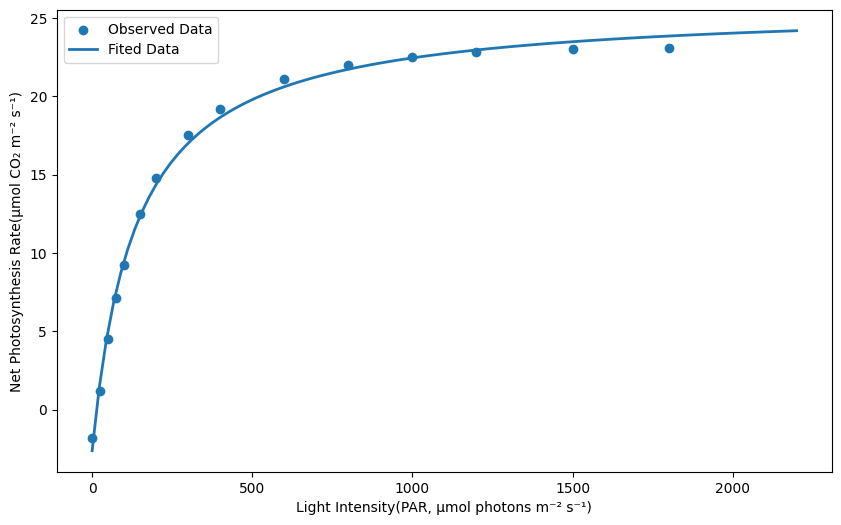

In [33]:
# Part C: Evaluate and interpret the model
import matplotlib.pyplot as plt

I_smooth=np.linspace(0,2200,100)
A_smooth=light_response(I_smooth,Amax_cf,K_cf,Rd_cf)
plt.figure(figsize=(10,6))
plt.scatter(par_data,photo_data,label='Observed Data')
plt.plot(I_smooth,A_smooth,linewidth=2,label='Fited Data')
plt.xlabel('Light Intensity(PAR, μmol photons m⁻² s⁻¹)')
plt.ylabel('Net Photosynthesis Rate(μmol CO₂ m⁻² s⁻¹)')
plt.legend()
plt.show()

---
## Submission Checklist

Before submitting, verify that:

- [ ] All code cells run without errors
- [ ] All three problems are complete
- [ ] Output is visible for all cells
- [ ] Your name and date are filled in below
- [ ] File is saved to the `homework` folder in your private GitHub repository
- [ ] File is committed and pushed **before the deadline**
- [ ] Link to your notebook is submitted on Canvas